# Analysis of the ParlaMint-SI corpus

This study presents a framework for analysis of Slovenian parliamentary debates integrating metadata analysis, linguistic methods and targeted case studies. The framework is structured into three interconnected layers, progressing from a broad overview of parliamentary discourse to a detailed case study of two major political parties.
The primary objective is to provide a comprehensive study of Slovenian parliamentary debates, capturing both macro-level trends and linguistic patterns in political discourse, while also analysing party behaviour and ideological shifts across legislative periods. The final layer offers an in-depth case study of Socialni Demokrati (SD) and Slovenska Demokratska Stranka (SDS), two parliamentary parties that were continuously represented in parliament during the period under review and occupy opposite positions on the political spectrum.

The framework is divided into three layers:
- Corpus-wide analysis, focussing on party-level analysis: To systematically analyse Slovenian parliamentary debates, this study adopts a corpus-based approach, where political parties and their corresponding parliamentary groups serve as the primary unit of analysis.
- Term-by-Term analysis: While the overall trends provide a broad overview of parliament and its debates, looking at the trends for each individual legislative period allows for a more detailed analysis of the political processes and trends that have taken place within the legislative period, as well as a link to specific political events.
- Case study analysis: conducting a comparison of two ideologically opposed parties that were present throughout the entire period covered by the ParlaMint-SI corpus.



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../Datasets/Sentiment_Analysis/ParlaMint-SI.tsv', delimiter='\t', encoding='utf-8')
df = df.drop_duplicates(subset=['ID']).reset_index(drop=True)

df.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovane kolegice in kolegi, gospe in gospodje!","Dear colleagues, ladies and gentlemen!",3.846659,3.88,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,NP,Poslanska skupina nepovezanih poslancev,-,-,ZorčičIgor,"Zorčič, Igor",M,1978
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala lepa, predsedujoči.","Thank you very much, Chairman.",4.019485,3.19,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMP,notMinister,-,-,-,-,SlavinecMitja,"Slavinec, Mitja",M,1964
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


Fixing Term 5-6 and Term 7-8 overlaps identified in the original data (debate transcriptions), corrected in ParlaMint-SI 5.0:

- Term 5: 15.10.2008 - 21.12.2011
- Term 6: 21.12.2011 - 01.08.2014
- Term 7: 01.08.2014 - 22.06.2018
- Term 8: 22.06.2018 - 13.05.2022


In [2]:
# Renaming slv metadata to eng (X. mandat -> Term X)
df['Term'] = df['Term'].replace({
    '3. mandat': 'Term 3',
    '4. mandat': 'Term 4',
    '5. mandat': 'Term 5',
    '6. mandat': 'Term 6',
    '7. mandat': 'Term 7',
    '8. mandat': 'Term 8'
})
df['Year'] = df['Date'].str.split('-').str[0]

term6 = df[df['Year'] == '2012']
update_term6 = term6.index
df.loc[update_term6, 'Term'] = 'Term 6'

term5_check = df[df['Term'] == 'Term 5']
print("Earliest Term5 speech: ", term5_check['Date'].min())
print("Last Term5 speech: ", term5_check['Date'].max())

term6_check = df[df['Term'] == 'Term 6']
print("Earliest Term6 speech: ", term6_check['Date'].min())
print("Last Term6 speech: ", term6_check['Date'].max())

term7 = df[(df['Date'] == '2018-10-11') & (df['ID'].str.contains('ParlaMint-SI_2018-10-11-SDZ7-Izredna-49.ana'))]
update_term7 = term7.index
df.loc[update_term7, 'Term'] = 'Term 8'

term7_check = df[df['Term'] == 'Term 7']
print("Earliest Term7 speech: ", term7_check['Date'].min())
print("Last Term7 speech: ", term7_check['Date'].max())

term8_check = df[df['Term'] == 'Term 8']
print("Earliest Term8 speech: ", term8_check['Date'].min())
print("Last Term8 speech: ", term8_check['Date'].max())


Earliest Term5 speech:  2008-10-15
Last Term5 speech:  2011-12-08
Earliest Term6 speech:  2011-12-21
Last Term6 speech:  2014-07-04
Earliest Term7 speech:  2014-08-01
Last Term7 speech:  2018-05-24
Earliest Term8 speech:  2018-06-22
Last Term8 speech:  2022-04-06


## Descriptive statistics

Checking distributions within the new ParlaMint-SI corpus and the characteristics of the political parties within

Corpus: 
- Total no. of speeches
- % of procedural speeches within the corpus (remove from the analysis)
- label distribution
- sentiment distribution overall (count, %)
- sentiment distribution across terms (count, %)
- sentiment distribution across political orientation (count, %)
- sentiment distribution across political status (coalition/opposition, (count, %))


In [3]:
df = df[df['Speaker_role'] == 'Regular']
df_procedural = df[df['Speaker_role'] != 'Regular']


df_labels = df['labels'].value_counts()
df_sentiment = df['sentiment'].value_counts()

percent_procedural = (len(df_procedural) / len(df)) * 100
percent_lables = (df_labels / len(df)) * 100
percent_sent = (df_sentiment / len(df)) * 100

print("Total no. of speeches: ", len(df))
print("Total no. of procedural speeches: ", len(df_procedural), "%: ", percent_procedural)
print("Earliest speech: ", df['Date'].min())
print("Last speech: ", df['Date'].max())
print("Distribution of the labels: ", percent_lables)
print("Distribution of the sentiment: ", percent_sent)


Total no. of speeches:  153763
Total no. of procedural speeches:  0 %:  0.0
Earliest speech:  2000-10-27
Last speech:  2022-04-06
Distribution of the labels:  labels
Negative            42.146030
Mixed Negative      17.854750
Neutral Negative    14.145796
Neutral Positive    13.048002
Mixed Positive       9.593986
Positive             3.211436
Name: count, dtype: float64
Distribution of the sentiment:  sentiment
Negative    60.000780
Neutral     27.193798
Positive    12.805421
Name: count, dtype: float64


In [4]:
parties = df['Speaker_party'].value_counts()
orientations = df['Party_orientation'].value_counts()
status = df['Party_status'].value_counts()

percent_parties = (parties / len(df)) * 100
percent_orientations = (orientations / len(df)) * 100
percent_staus = (status / len(df)) * 100

print("% of speeches per political party:", percent_parties)
print("% of speeches for coalition/opposition: ", percent_staus)
print("% of speeches per political orientation:", percent_orientations)

% of speeches per political party: Speaker_party
SDS          22.746044
-            12.466588
SD           10.836807
LDS           9.169956
NSi           8.687396
SNS           5.139078
SLS           4.690985
DeSUS         4.417187
SMC           3.906011
Levica        3.122988
ZLSD          2.340615
PS            2.073971
LMŠ           1.827488
Zares         1.814481
ZL            1.582956
SAB           1.271437
NP            1.097793
DL            0.684820
NeP           0.534589
SLS+SKD       0.526134
SMS           0.458498
Lipa          0.256889
ZaAB          0.212015
Konkretno     0.074790
DLGV          0.060483
Name: count, dtype: float64
% of speeches for coalition/opposition:  Party_status
Opposition    44.975709
Coalition     36.848917
-             18.175374
Name: count, dtype: float64
% of speeches per political orientation: Party_orientation
Right                     22.806527
Centre to centre-left     21.394614
Centre-left               16.933853
-                         1

In [5]:
status = df.groupby(['Speaker_party','Party_status']).size().unstack(fill_value=0)
status.columns = ['Total Speeches (Unknown)', 'Total Speeches (Coalition)', 'Total Speeches (Opposition)']

avg_sentiment = df.groupby(['Speaker_party', 'Party_status'])['utt_annotations'].mean().unstack(fill_value=0)
avg_sentiment.columns = ['Avg. Sentiment (Unknown)', 'Avg. Sentiment (Coalition)', 'Avg. Sentiment (Opposition)']

sentiment_counts = df.groupby(['Speaker_party', df['sentiment']]).size().unstack(fill_value=0)
sentiment_percentages = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

party_metadata = df[['Speaker_party', 'Party_orientation']].drop_duplicates().set_index('Speaker_party')

overview = (
    status
    .merge(avg_sentiment, on='Speaker_party', how='left')
    .merge(sentiment_percentages, on='Speaker_party', how='left')
    .reset_index()
)

overview = overview.merge(party_metadata, on='Speaker_party', how='left')

overview.rename(columns={
    'Positive': '% Positive',
    'Neutral': '% Neutral',
    'Negative': '% Negative'
}, inplace=True)


overview = overview[['Speaker_party', 'Party_orientation', 'Total Speeches (Coalition)', 'Total Speeches (Opposition)','Total Speeches (Unknown)',
               'Avg. Sentiment (Coalition)', 'Avg. Sentiment (Opposition)','Avg. Sentiment (Unknown)', '% Positive', '% Neutral', '% Negative']]

overview['Avg. Sentiment (Coalition)'] = overview['Avg. Sentiment (Coalition)'].apply(lambda x: f'{x:.2f}')
overview['Avg. Sentiment (Opposition)'] = overview['Avg. Sentiment (Opposition)'].apply(lambda x: f'{x:.2f}')
overview['Avg. Sentiment (Unknown)'] = overview['Avg. Sentiment (Unknown)'].apply(lambda x: f'{x:.2f}')
overview['% Positive'] = overview['% Positive'].apply(lambda x: f'{x:.2f}')
overview['% Neutral'] = overview['% Neutral'].apply(lambda x: f'{x:.2f}')
overview['% Negative'] = overview['% Negative'].apply(lambda x: f'{x:.2f}')



overview

,Speaker_party,Party_orientation,Total Speeches (Coalition),Total Speeches (Opposition),Total Speeches (Unknown),Avg. Sentiment (Coalition),Avg. Sentiment (Opposition),Avg. Sentiment (Unknown),% Positive,% Neutral,% Negative
0,-,-,0,0,19169,0.00,0.00,2.18,18.63,49.56,31.80
1,DL,Centre to centre-right,1000,50,3,1.82,2.03,1.30,20.80,28.21,51.00
2,DLGV,Right,55,0,38,2.23,0.00,3.02,41.94,21.51,36.56
3,DeSUS,Centre to centre-left,6608,181,3,2.08,2.63,3.20,27.65,28.40,43.95
4,Konkretno,Centre,115,0,0,2.90,0.00,0.00,46.96,28.70,24.35
5,LDS,Centre to centre-left,7644,6426,30,1.66,0.92,2.90,10.35,27.31,62.34
6,LMŠ,Centre to centre-left,557,2213,40,1.82,0.79,2.17,8.40,18.47,73.13
7,Levica,Left,0,4802,0,0.00,0.59,0.00,2.31,12.33,85.36
8,Lipa,-,0,0,395,0.00,0.00,0.83,4.05,18.99,76.96
9,NP,-,0,0,1688,0.00,0.00,1.14,11.91,16.23,71.86


In [6]:
#print(overview.to_latex(index=False))

#### Term overview (Party activity, ...)

Checking party activity and other trends that allow for a good term characteristics overview.
For these analyses, the question of how to treat "non-parties" (NeP and NP) and anomalys (such as Lipa, Konkretno) are directly tied to visualisation and data granularity. 
- NeP = parliamentary group of independent MPs, which could be considered for the analysis, however, since there is no destinction between different NePs in different mandates, this should be ruled out
- NP = individual independent MPs, not connected into a parliamentary group. In addition to them not being a formal parliamentary entity but individual speakers, they have similar problem as NeP, ruled out
- Lipa and Konkretno = both are non-parliamentary parties. Specfically, both parties were consistuted within Parliament after being elected as a different parliamentary party. Therefore, the party was never directly voted into the Parliament, however, individual MPs, that were elected into the Parliament are still MPs, but within a new party. Since they did produce some speeches within their (very short) terms, they should be kept in the analysis.
- '-' = individual speakers without formal political party affiliation. As we are interested in party activity, they will not be a part of the analysis.
- Some parties have been renamed during the course of their existence within the Parliament, and are in essence a direct continuation of one another:
    - ZL -> Levica
    - ZaAB -> ZaSLD -> SAB
    - ZLSD -> SD
    - SLS+SKD -> SLS
    - DLGV -> DL

Two versions of the Gantt plot: 
- Visualising party activity with parties as they are.
- Visualising party activity with grouped parties
- Ideally, both plots can be used (with different colour palette) within the Chapter

In [29]:
activity = df.groupby(['Term', 'Speaker_party']).agg(
    Start_date=('Date', 'min'),
    End_date=('Date', 'max'),
    Speech_count=('Date', 'size')  # Number of rows in the group (len())
).reset_index()
activity = activity[~activity['Speaker_party'].isin(["-", "NeP", "NP"])]
groups = {
    "ZL": "ZL/Levica",
    "Levica": "ZL/Levica",
    "ZaAB":"ZaAB/ZaSLD/SAB",
    "ZaSLD":"ZaAB/ZaSLD/SAB",
    "SAB" :"ZaAB/ZaSLD/SAB",
    "ZLSD":"ZLSD/SD",
    "SD":"ZLSD/SD",
    "SLS+SKD":"SLS+SKD/SLS",
    "SLS":"SLS+SKD/SLS", 
    "DLGV":"DLGV/DL", 
    "DL":"DLGV/DL"
}
activity["Grouped_parties"] = activity['Speaker_party'].replace(groups).fillna(activity['Speaker_party'])
activity.head()

,Term,Speaker_party,Start_date,End_date,Speech_count,Grouped_parties
1,Term 3,DeSUS,2000-10-27,2004-10-07,666,DeSUS
2,Term 3,LDS,2000-10-27,2004-10-07,6036,LDS
3,Term 3,NSi,2000-10-27,2004-10-07,4375,NSi
5,Term 3,SDS,2000-11-10,2004-10-07,5330,SDS
6,Term 3,SLS,2002-03-19,2004-10-07,1719,SLS+SKD/SLS


In [ ]:
import plotly.express as px
from PIL import Image

## Plot 1: ALL parties as are
fig = px.timeline(
    activity,
    x_start="Start_date",
    x_end="End_date",
    y="Speaker_party",
    color="Speech_count",
    title="Party Activity Across Terms (Gantt Chart)",
    labels={"Speech_count": "Party Activity"},
)
fig.update_layout(
    height=600  # Set the height to your desired value
)

#fig.write_html("../../Figures/Sentiment_Analysis/Parties/Party_activity_Gantt.html")
fig.write_image("../../Figures/Sentiment_Analysis/Parties/Party_activity_Gantt.png")

fig.show()

In [38]:
fig = px.timeline(
    activity,
    x_start="Start_date",
    x_end="End_date",
    y="Grouped_parties",
    color="Speech_count",
    title="Party Activity Across Terms (Gantt Chart)",
    labels={"Speech_count": "Party Activity"},
    color_continuous_scale="viridis"

)
fig.update_layout(
    height=600,
    xaxis_title="Years",
    yaxis_title="Political Parties",
    legend_title="Grouped Parties",
    barmode = "stack"
)
fig.write_image("../../Figures/Sentiment_Analysis/Parties/Party_activity_grouped.png")

fig.show()

## Checking label distribution (without procedural speech)

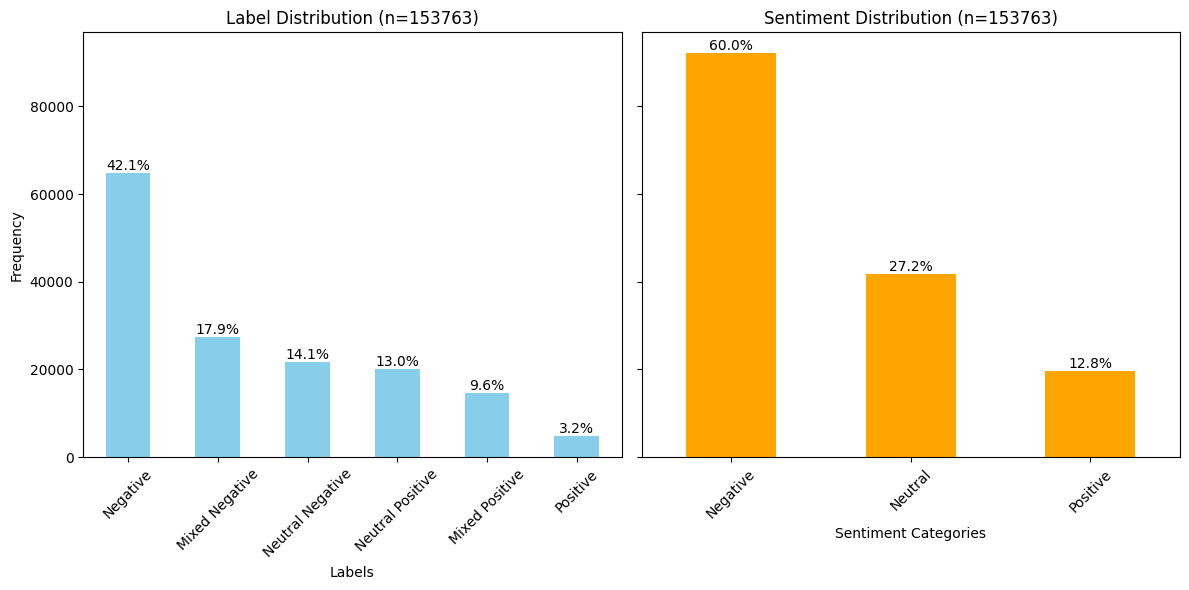

In [12]:
def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
df_labels.plot(kind='bar', ax=axes[0], color = 'skyblue')
axes[0].set_title('Label Distribution (n=153763)')
axes[0].set_xlabel('Labels')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], df_labels)

df_sentiment.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Sentiment Distribution (n=153763)')
axes[1].set_xlabel('Sentiment Categories')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], df_sentiment)

plt.tight_layout()
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_distribution.png', dpi=300)
plt.show()

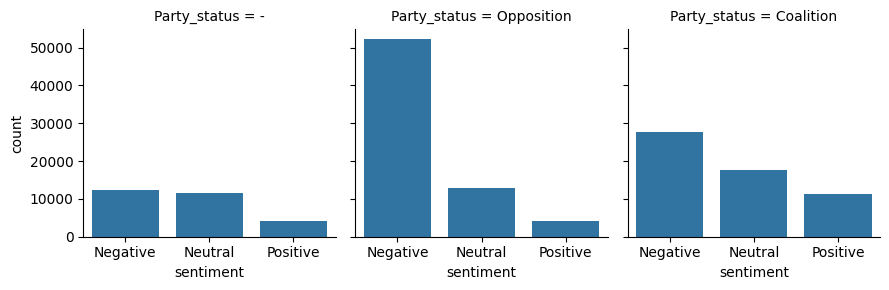

In [13]:
g = sns.FacetGrid(df, col="Party_status", margin_titles=True)
g.map(sns.countplot, "sentiment", order=["Negative", "Neutral", "Positive"])
#plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Party_status.png', dpi=300)
plt.show()

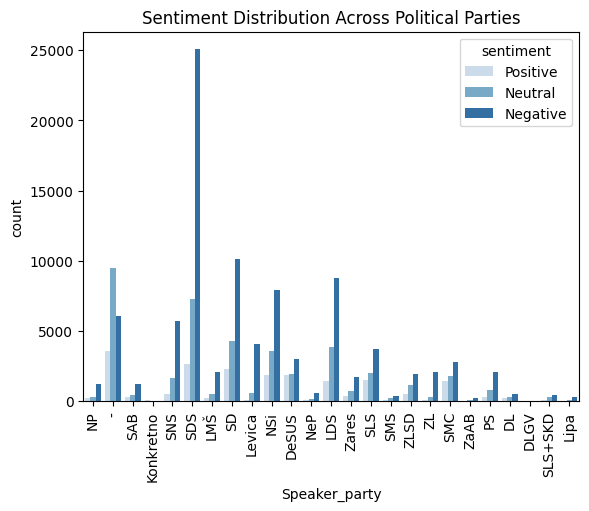

In [14]:
sns.countplot(data=df, x='Speaker_party', hue='sentiment', order=df['Speaker_party'].unique(), palette='Blues')
plt.xticks(rotation=90)
plt.title('Sentiment Distribution Across Political Parties')
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Political_parties.png', dpi=300)

plt.show()

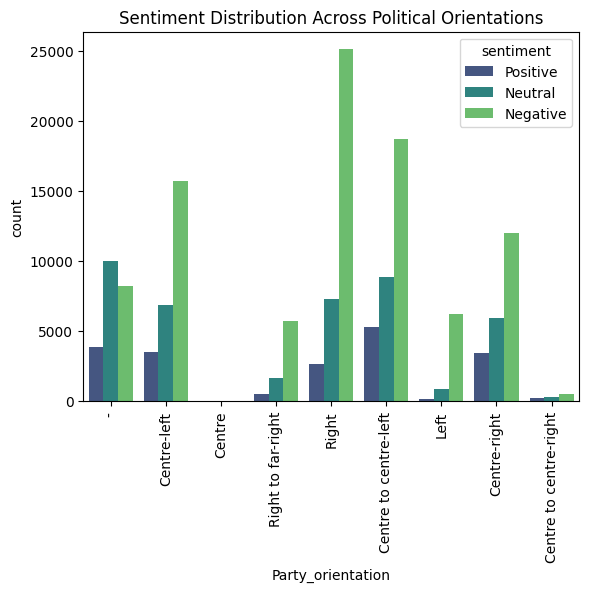

In [15]:
sns.countplot(data=df, x='Party_orientation', hue='sentiment', order=df['Party_orientation'].unique(), palette='viridis')
plt.xticks(rotation=90)
plt.title('Sentiment Distribution Across Political Orientations')
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Orientation.png', dpi=300)

plt.show()

## Percentage of Negative speeches per individual party/political orientation/party status
Different visualizations & checking percentage of negative speeches to get a better interpretations of the data


### Political parties

In [16]:
pivot_parties = pd.crosstab(df['Speaker_party'], df['sentiment'])
pivot_parties = pivot_parties.loc[pivot_parties.index != '-']

pivot_parties['Total'] = pivot_parties.sum(axis=1)
pivot_parties['% Negative'] = (pivot_parties['Negative'] / pivot_parties['Total']) * 100
pivot_parties['% Neutral'] = (pivot_parties['Neutral'] / pivot_parties['Total']) * 100
pivot_parties['% Positive'] = (pivot_parties['Positive'] / pivot_parties['Total']) * 100


pivot_parties['% Negative'] = pivot_parties['% Negative'].round(2)
pivot_parties['% Neutral'] = pivot_parties['% Neutral'].round(2)
pivot_parties['% Positive'] = pivot_parties['% Positive'].round(2)


pivot_parties

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Speaker_party,,,,,,,
DL,537,297,219,1053,51.00,28.21,20.80
DLGV,34,20,39,93,36.56,21.51,41.94
DeSUS,2985,1929,1878,6792,43.95,28.40,27.65
Konkretno,28,33,54,115,24.35,28.70,46.96
LDS,8790,3851,1459,14100,62.34,27.31,10.35
LMŠ,2055,519,236,2810,73.13,18.47,8.40
Levica,4099,592,111,4802,85.36,12.33,2.31
Lipa,304,75,16,395,76.96,18.99,4.05
NP,1213,274,201,1688,71.86,16.23,11.91


In [17]:
#print(pivot_parties.to_latex(multirow = True))

#### Percentages of Negative/Positive or Neutral speeches by parties

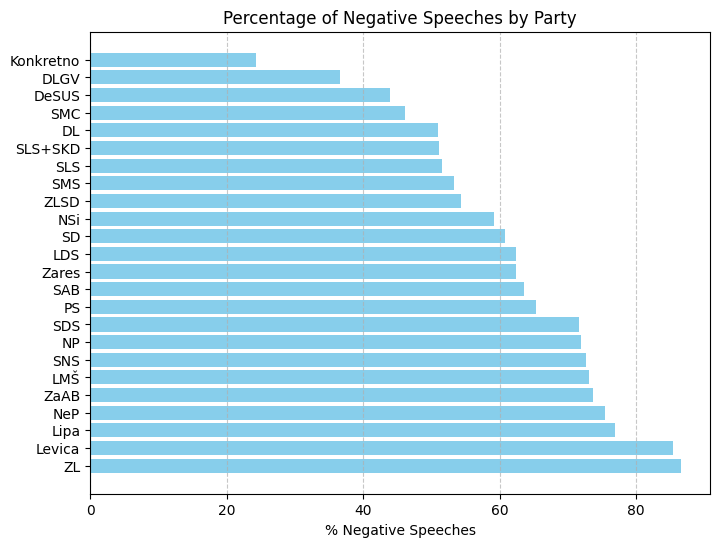

In [18]:
parties_negative = pivot_parties.sort_values('% Negative', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(parties_negative.index, parties_negative['% Negative'], color='skyblue')
plt.xlabel('% Negative Speeches')
plt.title('Percentage of Negative Speeches by Party')
plt.grid(axis='x', linestyle='--', alpha=0.7)
#plt.savefig('../../Figures/Sentiment_Analysis/Parties/Negative_Speech_by_Party.png', dpi=300)

plt.show()

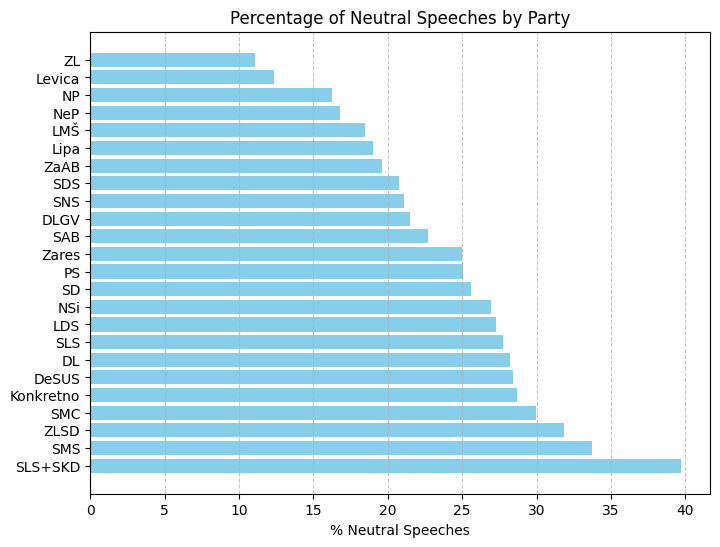

In [19]:
parties_neutral = pivot_parties.sort_values('% Neutral', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(parties_neutral.index, parties_neutral['% Neutral'], color='skyblue')
plt.xlabel('% Neutral Speeches')
plt.title('Percentage of Neutral Speeches by Party')
plt.grid(axis='x', linestyle='--', alpha=0.7)
#plt.savefig('../../Figures/Sentiment_Analysis/Parties/Netrual_Speech_by_Party.png', dpi=300)

plt.show()

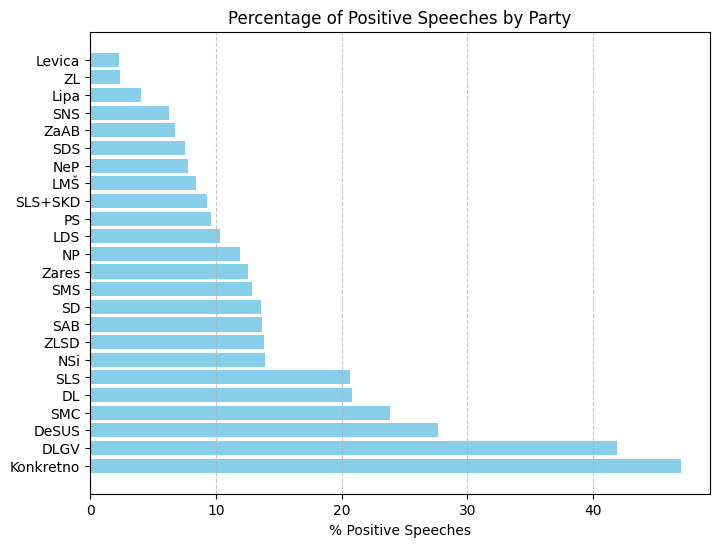

In [20]:
parties_positive = pivot_parties.sort_values('% Positive', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(parties_positive.index, parties_positive['% Positive'], color='skyblue')
plt.xlabel('% Positive Speeches')
plt.title('Percentage of Positive Speeches by Party')
plt.grid(axis='x', linestyle='--', alpha=0.7)
#plt.savefig('../../Figures/Sentiment_Analysis/Parties/Positive_Speech_by_Party.png', dpi=300)

plt.show()

Combining all of the above graphs into one visualisation for better interpretation

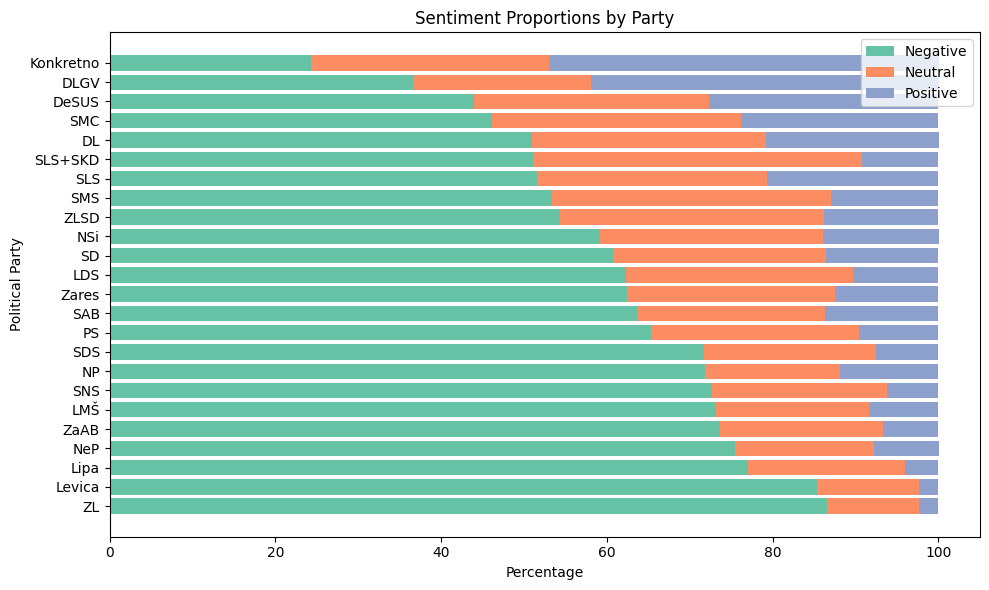

In [21]:
palette = sns.color_palette("Set2", 3)
pivot_parties = pivot_parties.sort_values(by='% Negative', ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_parties.index, pivot_parties['% Negative'], label='Negative',  color=palette[0])
ax.barh(pivot_parties.index, pivot_parties['% Neutral'], label='Neutral', left=pivot_parties['% Negative'], color=palette[1])
ax.barh(pivot_parties.index, pivot_parties['% Positive'], left=pivot_parties['% Negative'] + pivot_parties['% Neutral'], label='Positive', color=palette[2])

ax.set_ylabel('Political Party')
ax.set_xlabel('Percentage')
ax.set_title('Sentiment Proportions by Party')
ax.legend()

plt.tight_layout()
plt.savefig('../../Figures/Sentiment_Analysis/Parties/Party_Sentiment_proportions.png', dpi=300)
plt.show()

### Political orientations

In [22]:
pivot_orientation = pd.crosstab(df['Party_orientation'], df['sentiment'])
pivot_orientation = pivot_orientation.loc[pivot_orientation.index != '-']

pivot_orientation['Total'] = pivot_orientation.sum(axis=1)
pivot_orientation['% Negative'] = (pivot_orientation['Negative'] / pivot_orientation['Total'])*100
pivot_orientation['% Neutral'] = (pivot_orientation['Neutral'] / pivot_orientation['Total'])*100
pivot_orientation['% Positive'] = (pivot_orientation['Positive'] / pivot_orientation['Total'])*100

pivot_orientation['% Negative'] = pivot_orientation['% Negative'].round(2)
pivot_orientation['% Neutral'] = pivot_orientation['% Neutral'].round(2)
pivot_orientation['% Positive'] = pivot_orientation['% Positive'].round(2)

pivot_orientation

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Party_orientation,,,,,,,
Centre,28,33,54,115,24.35,28.70,46.96
Centre to centre-left,18685,8898,5314,32897,56.80,27.05,16.15
Centre to centre-right,537,297,219,1053,51.00,28.21,20.80
Centre-left,15683,6858,3497,26038,60.23,26.34,13.43
Centre-right,12037,5921,3422,21380,56.30,27.69,16.01
Left,6205,862,169,7236,85.75,11.91,2.34
Right,25109,7292,2667,35068,71.60,20.79,7.61
Right to far-right,5742,1665,495,7902,72.67,21.07,6.26


In [23]:
print(pivot_orientation.to_latex(multirow=True))

\begin{tabular}{lrrrrrrr}
\toprule
sentiment & Negative & Neutral & Positive & Total & % Negative & % Neutral & % Positive \\
Party_orientation &  &  &  &  &  &  &  \\
\midrule
Centre & 28 & 33 & 54 & 115 & 24.350000 & 28.700000 & 46.960000 \\
Centre to centre-left & 18685 & 8898 & 5314 & 32897 & 56.800000 & 27.050000 & 16.150000 \\
Centre to centre-right & 537 & 297 & 219 & 1053 & 51.000000 & 28.210000 & 20.800000 \\
Centre-left & 15683 & 6858 & 3497 & 26038 & 60.230000 & 26.340000 & 13.430000 \\
Centre-right & 12037 & 5921 & 3422 & 21380 & 56.300000 & 27.690000 & 16.010000 \\
Left & 6205 & 862 & 169 & 7236 & 85.750000 & 11.910000 & 2.340000 \\
Right & 25109 & 7292 & 2667 & 35068 & 71.600000 & 20.790000 & 7.610000 \\
Right to far-right & 5742 & 1665 & 495 & 7902 & 72.670000 & 21.070000 & 6.260000 \\
\bottomrule
\end{tabular}



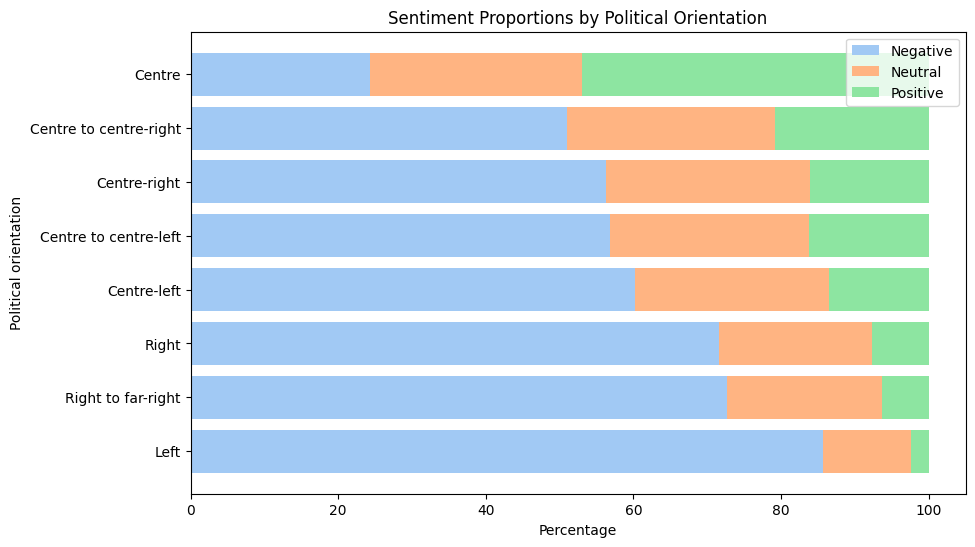

In [24]:
palette2 = sns.color_palette('pastel', 3)
pivot_orientation = pivot_orientation.sort_values(by='% Negative', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_orientation.index, pivot_orientation['% Negative'], label='Negative', color=palette2[0])
ax.barh(pivot_orientation.index, pivot_orientation['% Neutral'], left=pivot_orientation['% Negative'], label='Neutral', color=palette2[1])
ax.barh(pivot_orientation.index, pivot_orientation['% Positive'], left=pivot_orientation['% Negative'] + pivot_orientation['% Neutral'], label='Positive', color=palette2[2])

ax.set_ylabel("Political orientation")
ax.set_xlabel("Percentage")
ax.set_title("Sentiment Proportions by Political Orientation")
ax.legend()

plt.tight_layout
plt.savefig('../../Figures/Sentiment_Analysis/Orientation/Orientation_Sentiment_proportions.png', dpi=300)
plt.show()

### Political status

In [25]:
pivot_status = pd.crosstab(df['Party_status'], df['sentiment'])
pivot_status = pivot_status.loc[pivot_status.index != '-']

pivot_status['Total'] = pivot_status.sum(axis=1)
pivot_status['% Negative'] = (pivot_status['Negative'] / pivot_status['Total'])*100
pivot_status['% Neutral'] = (pivot_status['Neutral'] / pivot_status['Total'])*100
pivot_status['% Positive'] = (pivot_status['Positive'] / pivot_status['Total'])*100

pivot_status['% Negative'] = pivot_status['% Negative'].round(2)
pivot_status['% Neutral'] = pivot_status['% Neutral'].round(2)
pivot_status['% Positive'] = pivot_status['% Positive'].round(2)

pivot_status

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Party_status,,,,,,,
Coalition,27747,17548,11365,56660,48.97,30.97,20.06
Opposition,52201,12841,4114,69156,75.48,18.57,5.95


In [26]:
print(pivot_status.to_latex(multirow=True))

\begin{tabular}{lrrrrrrr}
\toprule
sentiment & Negative & Neutral & Positive & Total & % Negative & % Neutral & % Positive \\
Party_status &  &  &  &  &  &  &  \\
\midrule
Coalition & 27747 & 17548 & 11365 & 56660 & 48.970000 & 30.970000 & 20.060000 \\
Opposition & 52201 & 12841 & 4114 & 69156 & 75.480000 & 18.570000 & 5.950000 \\
\bottomrule
\end{tabular}



### Term

In [27]:
pivot_term = pd.crosstab(df['Term'], df['sentiment'])
pivot_term = pivot_term.loc[pivot_term.index != '-']

pivot_term['Total'] = pivot_term.sum(axis=1)
pivot_term['% Negative'] = (pivot_term['Negative'] / pivot_term['Total'])*100
pivot_term['% Neutral'] = (pivot_term['Neutral'] / pivot_term['Total'])*100
pivot_term['% Positive'] = (pivot_term['Positive'] / pivot_term['Total'])*100

pivot_term['% Negative'] = pivot_term['% Negative'].round(2)
pivot_term['% Neutral'] = pivot_term['% Neutral'].round(2)
pivot_term['% Positive'] = pivot_term['% Positive'].round(2)

pivot_term

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Term,,,,,,,
Term 3,15380,9561,2528,27469,55.99,34.81,9.20
Term 4,18588,8515,4251,31354,59.28,27.16,13.56
Term 5,15101,6880,3290,25271,59.76,27.22,13.02
Term 6,11496,4608,2373,18477,62.22,24.94,12.84
Term 7,16032,6200,3612,25844,62.03,23.99,13.98
Term 8,15662,6050,3636,25348,61.79,23.87,14.34


In [28]:
print(pivot_term.to_latex(multirow=True))

\begin{tabular}{lrrrrrrr}
\toprule
sentiment & Negative & Neutral & Positive & Total & % Negative & % Neutral & % Positive \\
Term &  &  &  &  &  &  &  \\
\midrule
Term 3 & 15380 & 9561 & 2528 & 27469 & 55.990000 & 34.810000 & 9.200000 \\
Term 4 & 18588 & 8515 & 4251 & 31354 & 59.280000 & 27.160000 & 13.560000 \\
Term 5 & 15101 & 6880 & 3290 & 25271 & 59.760000 & 27.220000 & 13.020000 \\
Term 6 & 11496 & 4608 & 2373 & 18477 & 62.220000 & 24.940000 & 12.840000 \\
Term 7 & 16032 & 6200 & 3612 & 25844 & 62.030000 & 23.990000 & 13.980000 \\
Term 8 & 15662 & 6050 & 3636 & 25348 & 61.790000 & 23.870000 & 14.340000 \\
\bottomrule
\end{tabular}



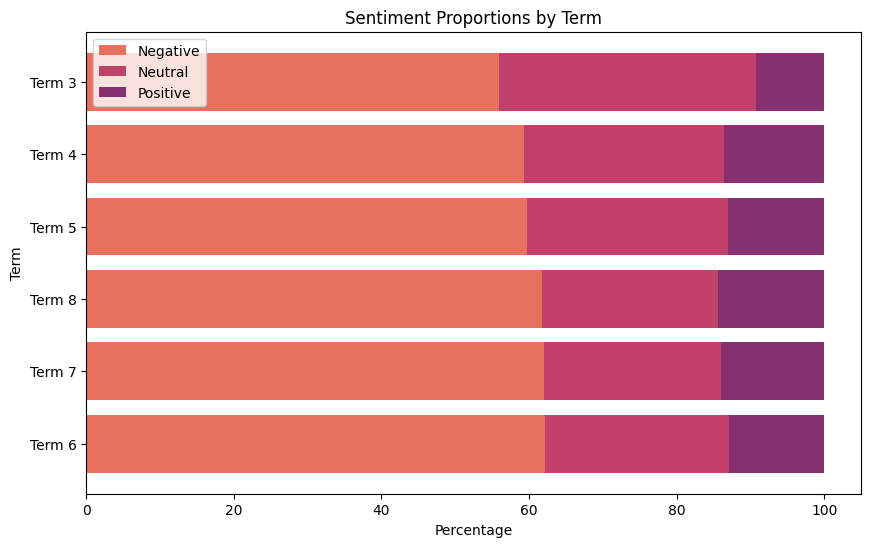

In [29]:
palette3 = sns.color_palette('flare', 3)
pivot_term = pivot_term.sort_values(by='% Negative', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_term.index, pivot_term['% Negative'], label='Negative', color=palette3[0])
ax.barh(pivot_term.index, pivot_term['% Neutral'], left=pivot_term['% Negative'], label='Neutral', color=palette3[1])
ax.barh(pivot_term.index, pivot_term['% Positive'], left=pivot_term['% Negative'] + pivot_term['% Neutral'], label='Positive', color=palette3[2])

ax.set_ylabel("Term")
ax.set_xlabel("Percentage")
ax.set_title("Sentiment Proportions by Term")
ax.legend()

plt.tight_layout
plt.savefig('../../Figures/Sentiment_Analysis/Terms/Term_Sentiment_proportions.png', dpi=300)
plt.show()

## Checking sentiment across terms

In [31]:
mandates = df[['ID', 'Term', 'Date', 'Year', 'utt_annotations', 'labels', 'sentiment', 'Speaker_party', 'Party_status', 'Party_orientation']]
mandates

,ID,Term,Date,Year,utt_annotations,labels,sentiment,Speaker_party,Party_status,Party_orientation
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,Term 8,2022-04-06,2022,3.88,Mixed Positive,Positive,NP,-,-
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,Term 8,2022-04-06,2022,3.19,Neutral Positive,Neutral,-,-,-
5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,Term 8,2022-04-06,2022,4.38,Mixed Positive,Positive,SAB,Opposition,Centre-left
7,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,Term 8,2022-04-06,2022,3.94,Mixed Positive,Positive,Konkretno,Coalition,Centre
9,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,Term 8,2022-04-06,2022,4.92,Positive,Positive,SNS,Opposition,Right to far-right
...,...,...,...,...,...,...,...,...,...,...
311337,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u237,Term 4,2005-01-24,2005,1.88,Neutral Negative,Neutral,NSi,Coalition,Centre-right
311339,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u239,Term 4,2005-01-24,2005,2.52,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left
311341,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u241,Term 4,2005-01-24,2005,1.49,Mixed Negative,Negative,LDS,Opposition,Centre to centre-left
311343,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,Term 4,2005-01-24,2005,2.75,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left


In [32]:
import numpy as np
#Droping the dferances, where the speakers are not affiliated with political parties
mandates.replace('-', np.nan, inplace=True)
print(len(mandates))

terms = mandates.copy()
terms['utt_annotations'] = pd.to_numeric(terms['utt_annotations'])
trends = terms.groupby(['Speaker_party', 'Term']).agg({'utt_annotations':'mean'}).reset_index()
trends['Term'] = pd.Categorical(trends['Term'], ordered=True)

trends


153763


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_60290/3261290792.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Speaker_party,Term,utt_annotations
0,DL,Term 6,1.827236
1,DLGV,Term 6,2.553871
2,DeSUS,Term 3,2.168994
3,DeSUS,Term 4,1.860725
4,DeSUS,Term 5,2.477836
...,...,...,...
59,ZLSD,Term 4,1.063720
60,ZaAB,Term 6,1.994286
61,ZaAB,Term 7,0.892525
62,Zares,Term 4,0.711831


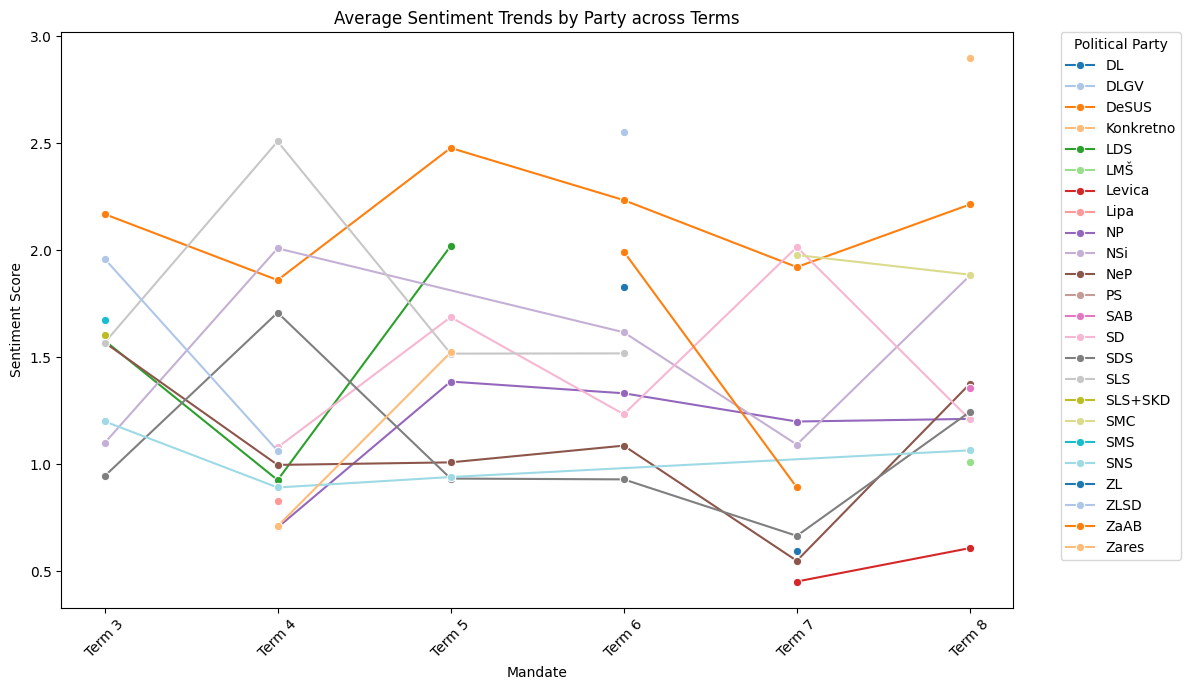

In [33]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=trends, x='Term', y='utt_annotations', hue='Speaker_party', marker='o', linewidth=1.5, palette='tab20')

plt.title('Average Sentiment Trends by Party across Terms')
plt.xlabel('Mandate')
plt.ylabel('Sentiment Score')
plt.legend(title='Political Party', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.xticks(rotation=45)
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_Trends.png', dpi=300)

plt.tight_layout()



## Checking sentiment trends within each term

In [35]:
government = pd.DataFrame({
    'Government': ['Gov5', 'Gov6', 'Gov7', 'Gov8', 'Gov9', 'Gov10', 'Gov11', 'Gov12', 'Gov13', 'Gov14'],
    'Start_Date': ['2000-06-07', '2000-12-01', '2002-12-20', '2004-12-04', '2008-11-22', '2012-02-11', '2013-03-21', '2014-09-19', '2018-09-14', '2020-03-14'],
    'End_Date': ['2000-11-30', '2002-12-19', '2004-12-03', '2008-11-21', '2012-02-10', '2013-03-20', '2014-09-18', '2018-09-13', '2020-03-13', '2022-06-01']
})

government['Start_Date'] = pd.to_datetime(government['Start_Date'])
government['End_Date'] = pd.to_datetime(government['End_Date'])
government
terms['Date'] = pd.to_datetime(terms['Date'])

def map_government(date):
    for _, row in government.iterrows():
        if row['Start_Date'] <= date <= row['End_Date']:
            return row['Government']
    return None

# Apply the function to add a new column
terms['Government'] = terms['Date'].apply(map_government)

terms

,ID,Term,Date,Year,utt_annotations,labels,sentiment,Speaker_party,Party_status,Party_orientation,Government
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,Term 8,2022-04-06,2022,3.88,Mixed Positive,Positive,NP,NaN,NaN,Gov14
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,Term 8,2022-04-06,2022,3.19,Neutral Positive,Neutral,NaN,NaN,NaN,Gov14
5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,Term 8,2022-04-06,2022,4.38,Mixed Positive,Positive,SAB,Opposition,Centre-left,Gov14
7,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,Term 8,2022-04-06,2022,3.94,Mixed Positive,Positive,Konkretno,Coalition,Centre,Gov14
9,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,Term 8,2022-04-06,2022,4.92,Positive,Positive,SNS,Opposition,Right to far-right,Gov14
...,...,...,...,...,...,...,...,...,...,...,...
311337,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u237,Term 4,2005-01-24,2005,1.88,Neutral Negative,Neutral,NSi,Coalition,Centre-right,Gov8
311339,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u239,Term 4,2005-01-24,2005,2.52,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left,Gov8
311341,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u241,Term 4,2005-01-24,2005,1.49,Mixed Negative,Negative,LDS,Opposition,Centre to centre-left,Gov8
311343,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,Term 4,2005-01-24,2005,2.75,Neutral Positive,Neutral,LDS,Opposition,Centre to centre-left,Gov8


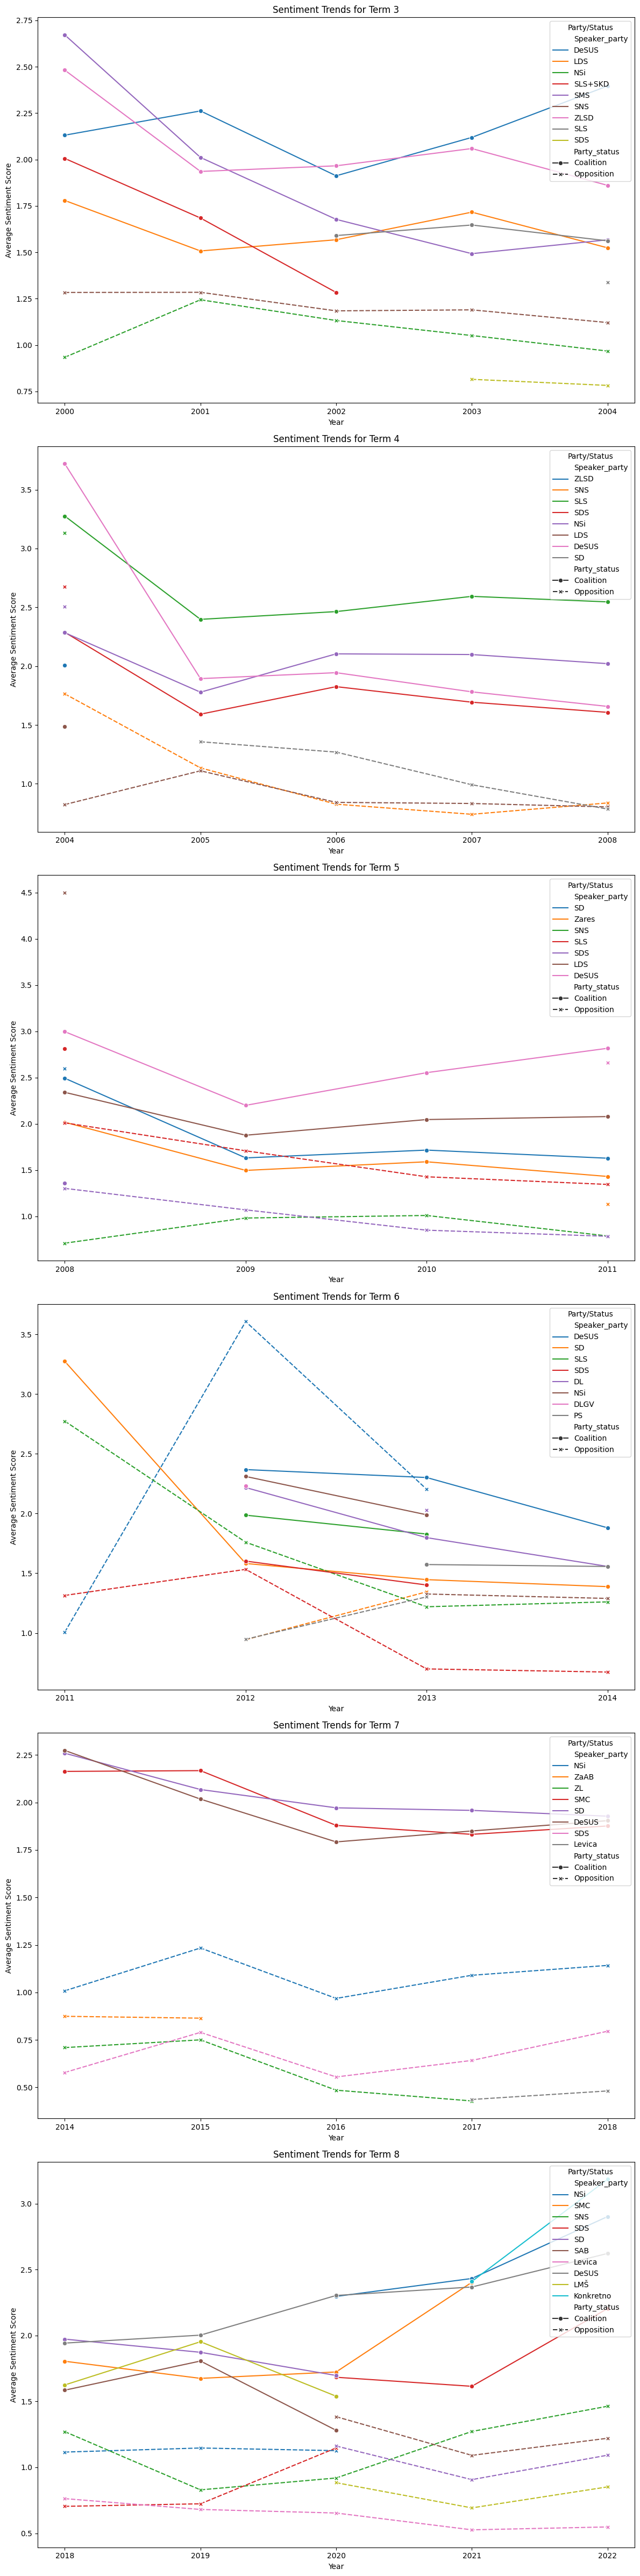

In [36]:
term_sent = terms.groupby(['Term', 'Year', 'Speaker_party', 'Party_status']).agg({'utt_annotations':'mean'}).reset_index()
term_sent['Party_status'] = term_sent['Party_status'].astype('category')
term_sent = term_sent.sort_values(by='Year', ascending=True)

## Giving each individual political party a colour to be tracked throughout the subplots (not distinctive enough)
#unique_parties = term_sent['Speaker_party'].unique()
#party_palette = sns.color_palette("Set2", n_colors=len(unique_parties))
#party_color_mapping = {party: party_palette[i] for i, party in enumerate(unique_parties)}


n_terms = term_sent['Term'].unique()


fig, axes = plt.subplots(len(n_terms), 1, figsize=(12, 8 * len(n_terms)))

for i, term in enumerate(n_terms):
    ax = axes[i] if len(n_terms) > 1 else axes
    term_data = term_sent[term_sent['Term'] == term]

    sns.lineplot(data=term_data, x='Year', y='utt_annotations', hue='Speaker_party', style='Party_status' , ax=ax, markers=True)
    ax.set_title(f"Sentiment Trends for {term}")
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Sentiment Score')
    ax.legend(title='Party/Status', loc='upper right')

plt.tight_layout()
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_for_Terms.png', dpi=300)

plt.show()



Interpretation of the trends witih individual mandate:

-Term 6: The overlap between the coalition and opposition values for certain political parties is due to the fact that there is a change in the government - Term 6 observes multiple government structures in its duration, namely: 
- 9. Vlada Republike Slovenije (21. 11. 2008 - 10. 2. 2012)
predsednik vlade Borut Pahor
- 10. Vlada Republike Slovenije (10. 2. 2012 - 20. 3. 2013)
predsednik vlade Janez Janša
- 11. Vlada Republike Slovenije (20. 3. 2013 - 18. 9. 2014)
predsednica vlade mag. Alenka Bratušek



In [37]:
###Generating individual plots for a paper/chapter
for term in n_terms:
    term_data = term_sent[term_sent['Term'] == term]
    
    plt.figure(figsize=(12, 8))
    
    sns.lineplot(data=term_data, x='Year', y='utt_annotations', hue='Speaker_party',
                 style='Party_status', markers=True)
    
    plt.title(f"Sentiment Trends for {term}")
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment Score')
    plt.legend(title='Party/Status', loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f'../../Figures/Sentiment_Analysis/Terms/Sentiment_{term}.png', dpi=300)
    
    plt.close()

In [38]:
term_sent.to_csv('../../Tables/Terms.csv', encoding='utf-8', index=False)

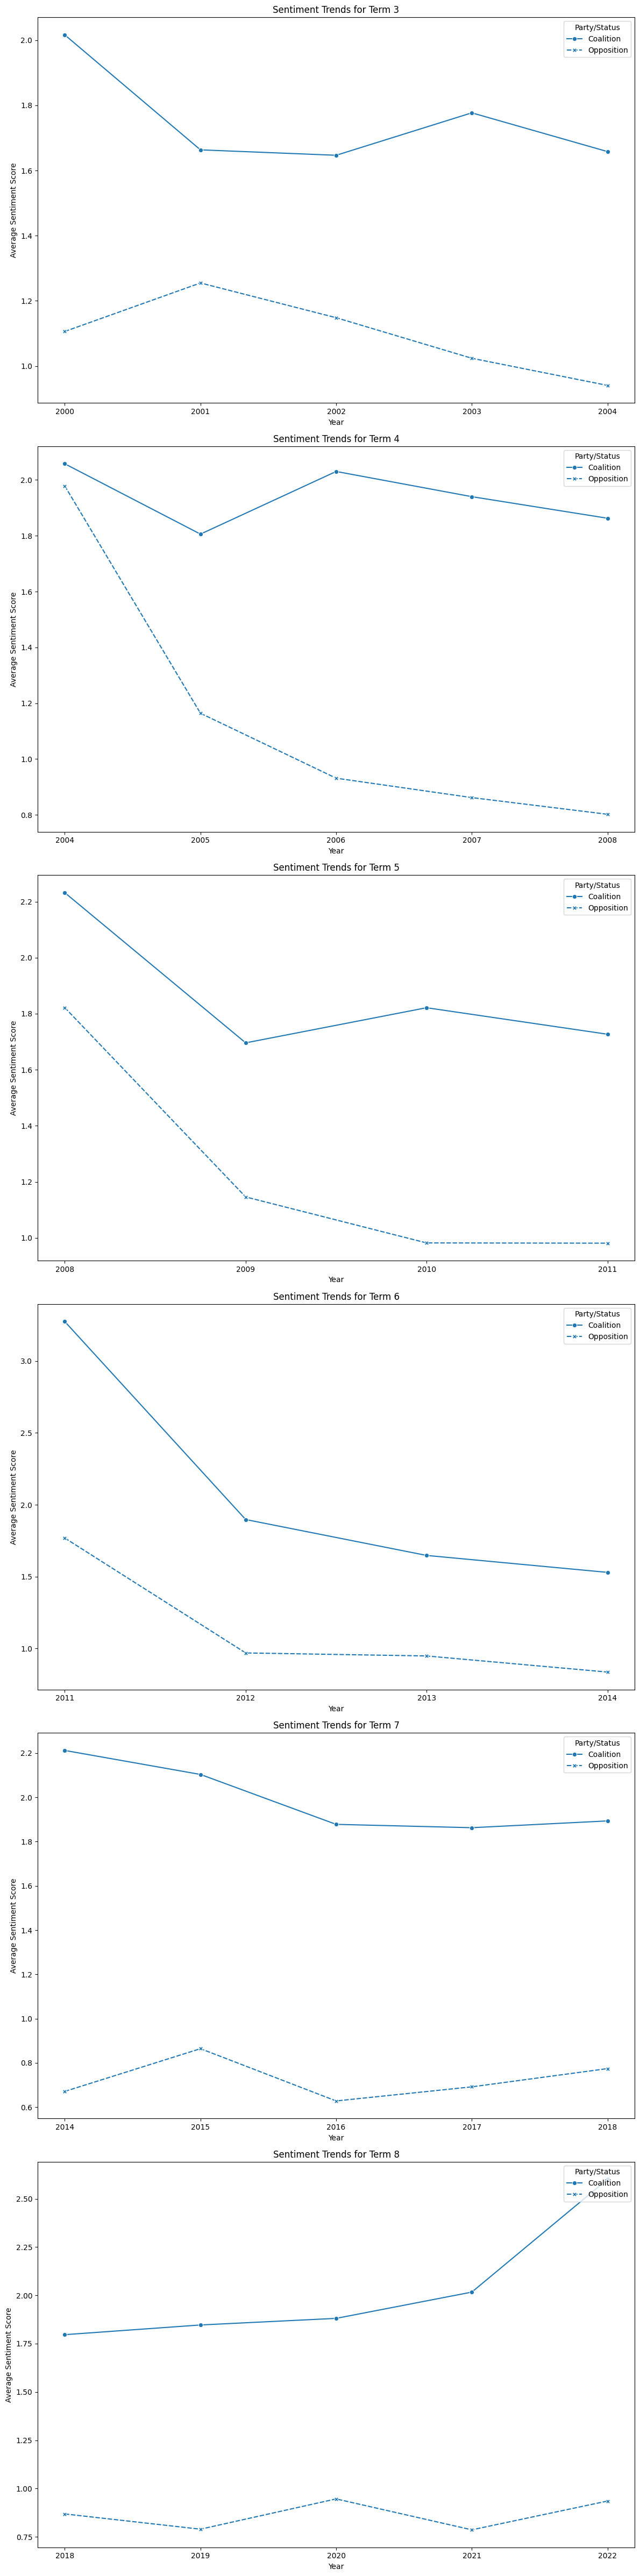

In [39]:
status = terms.groupby(['Term', 'Year', 'Party_status']).agg({'utt_annotations':'mean'}).reset_index()
status['Party_status'] = status['Party_status'].astype('category')
status = status.sort_values(by='Year', ascending=True)

## Giving each individual political party a colour to be tracked throughout the subplots (not distinctive enough)
#unique_parties = term_sent['Speaker_party'].unique()
#party_palette = sns.color_palette("Set2", n_colors=len(unique_parties))
#party_color_mapping = {party: party_palette[i] for i, party in enumerate(unique_parties)}


n_terms = status['Term'].unique()


fig, axes = plt.subplots(len(n_terms), 1, figsize=(12, 8 * len(n_terms)))

for i, term in enumerate(n_terms):
    ax = axes[i] if len(n_terms) > 1 else axes
    term_data = status[status['Term'] == term]

    sns.lineplot(data=term_data, x='Year', y='utt_annotations', style='Party_status' , ax=ax, markers=True)
    ax.set_title(f"Sentiment Trends for {term}")
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Sentiment Score')
    ax.legend(title='Party/Status', loc='upper right')

plt.tight_layout()
#plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_for_Terms.png', dpi=300)

plt.show()

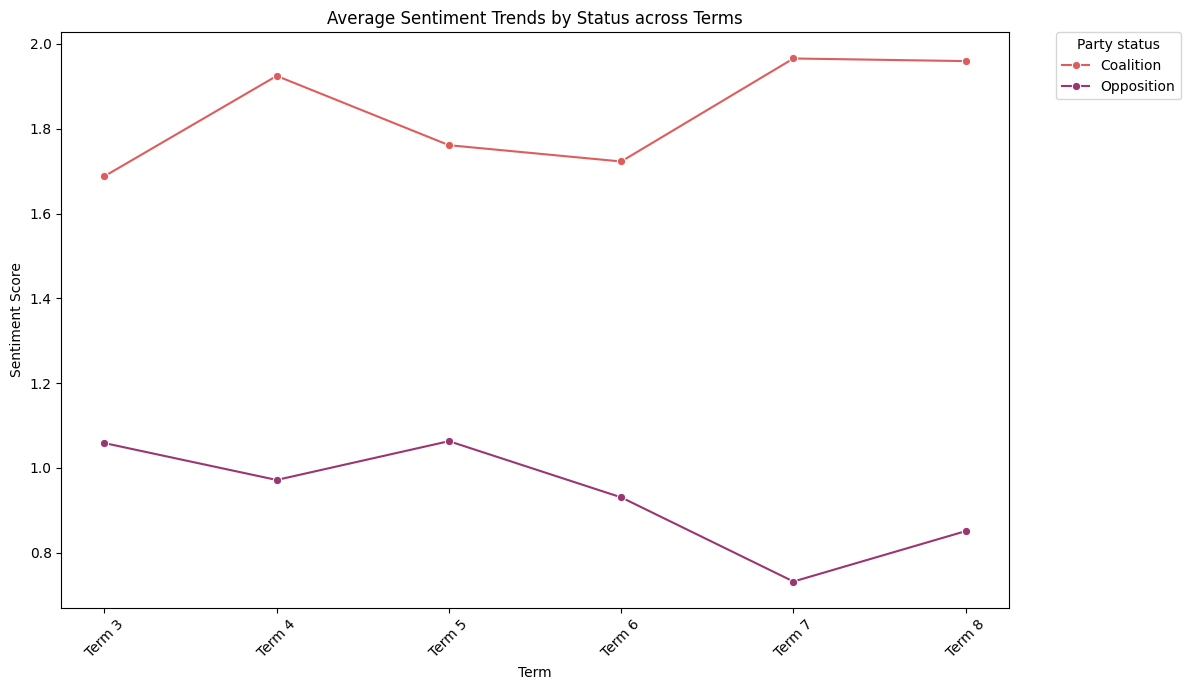

In [40]:
terms_status = mandates.copy()
terms_status['utt_annotations'] = pd.to_numeric(terms_status['utt_annotations'])
trends_status = terms_status.groupby(['Party_status', 'Term']).agg({'utt_annotations':'mean'}).reset_index()
trends_status['Term'] = pd.Categorical(trends_status['Term'], ordered=True)

trends_status

plt.figure(figsize=(12, 7))

sns.lineplot(data=trends_status, x='Term', y='utt_annotations', hue='Party_status', marker='o', linewidth=1.5, palette='flare')

plt.title('Average Sentiment Trends by Status across Terms')
plt.xlabel('Term')
plt.ylabel('Sentiment Score')
plt.legend(title='Party status', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.xticks(rotation=45)
plt.savefig('../../Figures/Sentiment_Analysis/Status_Trends.png', dpi=300)

plt.tight_layout()